# Experiment 3 GRU-D Observation-Frequency Shift

This notebook analyzes the GRU-D Experiment 3 comparison without mixing LSTM runs into the main result tables.

Main regimes:

- dense -> dense
- dense -> structured-r8
- structured-r8 -> structured-r8

The primary mismatch penalty is matched sparse performance minus mismatched sparse performance:

`M(structured-r8 -> structured-r8) - M(dense -> structured-r8)`

For Brier score, lower is better, so the displayed improvement is `Brier(dense -> structured-r8) - Brier(structured-r8 -> structured-r8)`. Positive values therefore mean the matched model has lower/better Brier.

In [1]:
EXP3_GRUD_ALLOW_PARTIAL_RESULTS = True
EXP3_GRUD_REQUIRE_COMPLETE_EPOCHS = False
# Missing test predictions are generated automatically.
# Set this to True only when intentionally regenerating ALL GRU-D test predictions in this notebook.
RERUN_ALL_TEST_INFERENCE = False

## Configuration

The scanner only considers GRU-D logs whose filename starts with `k_grud`. Filename parsing verifies the hyperparameters encoded in the run name: hidden dimension, dropout, depth, horizon, batch size, timestep, seed, and the optional train sampling suffix. Non-filename fields used for test inference follow the known GRU-D experiment configuration.

In [2]:
from pathlib import Path
import os
import re
import shlex
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from visualize_utils import (
    DEFAULT_BOOTSTRAP_SEED,
    across_seed_patient_bootstrap,
    find_selected_checkpoint,
    load_prediction_csv,
    metric_difference,
    paired_patient_bootstrap,
    paired_prediction_frame,
    prediction_metrics,
    read_validation_log,
    show_table,
    summarize_with_t_ci,
)

PROJECT_DATA_ROOT = Path(os.environ.get(
    "PROJECT_DATA_ROOT",
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo",
))
EXP3_GRUD_REPO_DIR = Path.cwd().parent if Path.cwd().name == "visualizers" else Path.cwd()
EXP3_GRUD_PYTHON = os.environ.get("EXP3_GRUD_PYTHON", os.environ.get("EXP3_PYTHON", "python"))
EXP3_GRUD_DATA_DIR = PROJECT_DATA_ROOT / "data/length-of-stay"
EXP3_GRUD_NORMALIZER_DIR = PROJECT_DATA_ROOT / "normalizers"
EXP3_GRUD_RESULTS_DIR = PROJECT_DATA_ROOT / "results/fixed_horizon_icu_exit"
EXP3_GRUD_OUTPUT_DIR = EXP3_GRUD_RESULTS_DIR / "plots"
EXP3_GRUD_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXP3_GRUD_NETWORK = "mimic4models/keras_models/grud.py"
EXP3_GRUD_HORIZON = 12
EXP3_GRUD_R = 8
EXP3_GRUD_EXPECTED_MODEL_SEEDS = {0, 1, 2, 3, 4}
EXP3_GRUD_EXPECTED_EPOCHS = 100
EXP3_GRUD_TIMESTEP = 1.0
EXP3_GRUD_METRICS = ["auprc", "auroc", "brier"]
EXP3_GRUD_N_BOOT = int(os.environ.get("EXP3_GRUD_N_BOOT", os.environ.get("EXP3_N_BOOT", "2000")))
EXP3_GRUD_BOOTSTRAP_SEED = DEFAULT_BOOTSTRAP_SEED

EXP3_GRUD_EXPECTED_CONFIG = {
    "network": EXP3_GRUD_NETWORK,
    "dim": 16,
    "depth": 1,
    "dropout": 0.3,
    "rec_dropout": 0.0,
    "batch_norm": False,
    "batch_size": 8,
    "timestep": EXP3_GRUD_TIMESTEP,
    "target_repl_coef": 0.0,
    "l1": 0.0,
    "l2": 0.0,
    "optimizer": "adam",
    "lr": 0.001,
    "beta_1": 0.9,
    "imputation": "previous",
    "prefix": "",
}

print("GRU-D result root:", EXP3_GRUD_RESULTS_DIR)
print("Expected model seeds:", sorted(EXP3_GRUD_EXPECTED_MODEL_SEEDS))
print("Target comparison: dense->dense, dense->structured-r8, structured-r8->structured-r8")
print("Missing test predictions: AUTO-RUN")
print("Rerun all existing test predictions:", RERUN_ALL_TEST_INFERENCE)
if RERUN_ALL_TEST_INFERENCE:
    print("WARNING: ALL eligible GRU-D test predictions in this notebook will be regenerated.")

GRU-D result root: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit
Expected model seeds: [0, 1, 2, 3, 4]
Target comparison: dense->dense, dense->structured-r8, structured-r8->structured-r8
Missing test predictions: AUTO-RUN
Rerun all existing test predictions: False


## GRU-D Run Discovery

The discovery path is:

`validation log -> complete/incomplete epoch status -> validation-AUPRC-selected CSV epoch -> checkpoint epoch = CSV epoch + 1 -> exact checkpoint file -> exact expected prediction filename`

The checkpoint epoch offset is preserved because Keras CSVLogger epochs are zero-based while checkpoint filenames are one-based.

In [3]:
def _search(pattern, text, cast=None, default=None):
    m = re.search(pattern, text)
    if m is None:
        return default
    value = m.group(1)
    return cast(value) if cast is not None else value


def parse_sampling_from_name(name):
    sample = re.search(
        r"\.sample(?P<strategy>structured|random_matched)"
        r"\.r(?P<interval>\d+)"
        r"(?:\.sseed(?P<sseed>\d+))?",
        name,
    )
    if sample is None:
        return "none", None, None
    strategy = sample.group("strategy")
    interval = int(sample.group("interval"))
    seed = sample.group("sseed")
    return strategy, interval, int(seed) if seed is not None else None


def parse_grud_log_name(log_path, run_kind):
    name = log_path.name
    if not name.startswith("k_grud"):
        raise ValueError("Not a GRU-D log filename: {}".format(name))
    strategy, interval, sampling_seed = parse_sampling_from_name(name)
    l1 = _search(r"\.L1([0-9.eE+-]+)(?=\.|$)", name, float, 0.0)
    l2 = _search(r"\.L2([0-9.eE+-]+)(?=\.|$)", name, float, 0.0)
    return {
        "model": "GRU-D",
        "filename": name,
        "run_kind": run_kind,
        "horizon": _search(r"\.h(\d+)", name, int),
        "timestep": _search(r"\.ts([0-9]+(?:\.[0-9]+)?)(?=\.|$)", name, float),
        "model_seed": _search(r"\.seed(\d+)(?:\.|$)", name, int),
        "train_sampling_strategy": strategy,
        "train_sampling_interval": interval,
        "train_sampling_seed": sampling_seed,
        "dim": _search(r"\.n(\d+)", name, int),
        "dropout": _search(r"\.d([0-9]+(?:\.[0-9]+)?)(?=\.|$)", name, float, 0.0),
        "rec_dropout": _search(r"\.rd([0-9]+(?:\.[0-9]+)?)(?=\.|$)", name, float, 0.0),
        "batch_norm": re.search(r"\.bn(?=\.|$)", name) is not None,
        "depth": _search(r"\.dep(\d+)", name, int),
        "batch_size": _search(r"\.bs(\d+)", name, int),
        "target_repl_coef": _search(r"\.trc([0-9]+(?:\.[0-9]+)?)(?=\.|$)", name, float, 0.0),
        "l1": l1,
        "l2": l2,
        "log_path": str(log_path),
        "output_dir": str(log_path.parent.parent),
        "network": EXP3_GRUD_NETWORK,
        "optimizer": EXP3_GRUD_EXPECTED_CONFIG["optimizer"],
        "lr": EXP3_GRUD_EXPECTED_CONFIG["lr"],
        "beta_1": EXP3_GRUD_EXPECTED_CONFIG["beta_1"],
        "imputation": EXP3_GRUD_EXPECTED_CONFIG["imputation"],
        "prefix": EXP3_GRUD_EXPECTED_CONFIG["prefix"],
    }


def _float_mismatch(actual, expected, tol=1e-9):
    if actual is None:
        return True
    return abs(float(actual) - float(expected)) > tol


def grud_hyperparameter_mismatch_reason(run):
    reasons = []
    for key in ["dim", "depth", "batch_size"]:
        if run.get(key) != EXP3_GRUD_EXPECTED_CONFIG[key]:
            reasons.append("{}={} expected {}".format(key, run.get(key), EXP3_GRUD_EXPECTED_CONFIG[key]))
    for key in ["dropout", "rec_dropout", "target_repl_coef", "l1", "l2", "timestep"]:
        if _float_mismatch(run.get(key), EXP3_GRUD_EXPECTED_CONFIG[key]):
            reasons.append("{}={} expected {}".format(key, run.get(key), EXP3_GRUD_EXPECTED_CONFIG[key]))
    if run.get("horizon") != EXP3_GRUD_HORIZON:
        reasons.append("horizon={} expected {}".format(run.get("horizon"), EXP3_GRUD_HORIZON))
    if bool(run.get("batch_norm")) != bool(EXP3_GRUD_EXPECTED_CONFIG["batch_norm"]):
        reasons.append("batch_norm={} expected {}".format(run.get("batch_norm"), EXP3_GRUD_EXPECTED_CONFIG["batch_norm"]))
    if run.get("model_seed") not in EXP3_GRUD_EXPECTED_MODEL_SEEDS:
        reasons.append("model_seed={} not in expected {}".format(run.get("model_seed"), sorted(EXP3_GRUD_EXPECTED_MODEL_SEEDS)))
    return "; ".join(reasons)


def sampling_label(strategy, interval, seed=None):
    if strategy == "none":
        return "dense"
    if strategy == "structured":
        return "structured-r{}".format(int(interval))
    if strategy == "random_matched":
        return "random-r{}".format(int(interval))
    raise ValueError("Unknown sampling strategy {}".format(strategy))


def regime_label(train_strategy, train_interval, test_strategy, test_interval):
    return "{}->{}".format(
        sampling_label(train_strategy, train_interval),
        sampling_label(test_strategy, test_interval),
    )


def effective_sampling_regime(strategy, interval, seed):
    if strategy == "none":
        return ("none",)
    if strategy == "structured":
        return ("structured", int(interval))
    if strategy == "random_matched":
        return ("random_matched", int(interval), seed)
    raise ValueError("Unknown sampling strategy {}".format(strategy))


def regimes_match(train_strategy, train_interval, train_seed, test_strategy, test_interval, test_seed):
    return effective_sampling_regime(train_strategy, train_interval, train_seed) == effective_sampling_regime(
        test_strategy, test_interval, test_seed)


def test_sampling_suffix(strategy, interval, seed):
    if strategy == "none":
        return "testsample-none"
    label = "testsample-{}-r{}".format(strategy, int(interval))
    if strategy == "random_matched":
        label += "-sseed{}".format(seed)
    return label


def expected_prediction_path(output_dir, checkpoint, train_strategy, train_interval, train_seed,
                             test_strategy, test_interval, test_seed):
    pred_dir = Path(output_dir) / "test_predictions"
    base = pred_dir / checkpoint.name
    if regimes_match(train_strategy, train_interval, train_seed, test_strategy, test_interval, test_seed):
        return Path(str(base) + ".csv")
    return Path(str(base) + ".{}.csv".format(test_sampling_suffix(test_strategy, test_interval, test_seed)))


def parse_prediction_test_regime(prediction_path, checkpoint, train_strategy, train_interval, train_seed):
    name = Path(prediction_path).name
    matched_name = checkpoint.name + ".csv"
    if name == matched_name:
        return train_strategy, train_interval, train_seed, "matched-original-filename"
    prefix = checkpoint.name + ".testsample-"
    if not (name.startswith(prefix) and name.endswith(".csv")):
        raise ValueError("Prediction file does not match checkpoint naming convention: {}".format(prediction_path))
    label = name[len(prefix):-4]
    if label == "none":
        return "none", None, None, "explicit-testsample-suffix"
    m = re.match(r"(?P<strategy>structured|random_matched)-r(?P<interval>\d+)(?:-sseed(?P<seed>\d+))?$", label)
    if m is None:
        raise ValueError("Unrecognized test-sampling suffix in {}".format(prediction_path))
    strategy = m.group("strategy")
    interval = int(m.group("interval"))
    seed = m.group("seed")
    return strategy, interval, int(seed) if seed is not None else None, "explicit-testsample-suffix"

In [4]:
def normalizer_candidates_for_regime(strategy, interval, seed):
    if strategy == "none":
        pattern = "fixed_horizon_icu_exit_ts:{:.2f}_impute:{}_start:zero_masks:True_n:*.normalizer".format(
            EXP3_GRUD_TIMESTEP, EXP3_GRUD_EXPECTED_CONFIG["imputation"])
    elif strategy == "structured":
        pattern = (
            "fixed_horizon_icu_exit_sampling:structured_r:{}_ts:{:.2f}"
            "_impute:{}_start:zero_masks:True_n:*.normalizer"
        ).format(int(interval), EXP3_GRUD_TIMESTEP, EXP3_GRUD_EXPECTED_CONFIG["imputation"])
    elif strategy == "random_matched":
        pattern = (
            "fixed_horizon_icu_exit_sampling:random_matched_r:{}_seed:{}_ts:{:.2f}"
            "_impute:{}_start:zero_masks:True_n:*.normalizer"
        ).format(int(interval), int(seed), EXP3_GRUD_TIMESTEP, EXP3_GRUD_EXPECTED_CONFIG["imputation"])
    else:
        raise ValueError("Unknown normalizer strategy {}".format(strategy))
    return sorted(EXP3_GRUD_NORMALIZER_DIR.glob(pattern))


def resolve_normalizer_for_training_regime(strategy, interval, seed):
    candidates = normalizer_candidates_for_regime(strategy, interval, seed)
    if len(candidates) != 1:
        raise RuntimeError(
            "Expected exactly one normalizer for {} but found {}: {}".format(
                effective_sampling_regime(strategy, interval, seed), len(candidates), [str(x) for x in candidates]))
    return candidates[0]


def quote_command(cmd):
    return " ".join(shlex.quote(str(x)) for x in cmd)


def build_inference_command_parts(row):
    # Normalizer is intentionally selected from the training regime, never the test regime.
    normalizer_path = row.get("normalizer_path")
    if not normalizer_path:
        normalizer_path = str(resolve_normalizer_for_training_regime(
            row["train_sampling_strategy"], row["train_sampling_interval"], row["train_sampling_seed"]))
    cmd = [
        EXP3_GRUD_PYTHON, "-m", "mimic4models.fixed_horizon_icu_exit.main",
        "--mode", "test",
        "--network", EXP3_GRUD_NETWORK,
        "--data", str(EXP3_GRUD_DATA_DIR),
        "--normalizer_dir", str(EXP3_GRUD_NORMALIZER_DIR),
        "--normalizer_state", str(normalizer_path),
        "--output_dir", row["output_dir"],
        "--load_state", row["checkpoint_path"],
        "--horizon", str(int(row["horizon"])),
        "--timestep", str(row["timestep"]),
        "--seed", str(int(row["model_seed"])),
        "--dim", str(int(row["dim"])),
        "--depth", "1",
        "--dropout", str(row["dropout"]),
        "--rec_dropout", str(row["rec_dropout"]),
        "--batch_size", str(int(row["batch_size"])),
        "--target_repl_coef", str(row["target_repl_coef"]),
        "--l1", str(row["l1"]),
        "--l2", str(row["l2"]),
        "--optimizer", row["optimizer"],
        "--lr", str(row["lr"]),
        "--beta_1", str(row["beta_1"]),
        "--imputation", row["imputation"],
        "--prefix", row["prefix"],
        "--sampling_strategy", row["train_sampling_strategy"],
    ]
    if bool(row.get("batch_norm")):
        cmd += ["--batch_norm", "True"]
    if row["train_sampling_strategy"] != "none":
        cmd += ["--sampling_interval", str(int(row["train_sampling_interval"]))]
    if row["train_sampling_seed"] is not None and not pd.isnull(row["train_sampling_seed"]):
        cmd += ["--sampling_seed", str(int(row["train_sampling_seed"]))]
    if not regimes_match(row["train_sampling_strategy"], row["train_sampling_interval"], row["train_sampling_seed"],
                         row["test_sampling_strategy"], row["test_sampling_interval"], row["test_sampling_seed"]):
        cmd += ["--test_sampling_strategy", row["test_sampling_strategy"]]
        if row["test_sampling_strategy"] != "none":
            cmd += ["--test_sampling_interval", str(int(row["test_sampling_interval"]))]
        if row["test_sampling_seed"] is not None and not pd.isnull(row["test_sampling_seed"]):
            cmd += ["--test_sampling_seed", str(int(row["test_sampling_seed"]))]
    return cmd


def run_test_inference_for_row(row):
    expected = Path(row["expected_prediction_path"])
    if expected.exists() and not RERUN_ALL_TEST_INFERENCE:
        return "found-existing"
    cmd = build_inference_command_parts(row)
    print("Running test inference:", quote_command(cmd))
    subprocess.run(cmd, cwd=str(EXP3_GRUD_REPO_DIR), check=True)
    if not expected.exists():
        raise RuntimeError("Inference completed but expected prediction was not created: {}".format(expected))
    return "generated" if not RERUN_ALL_TEST_INFERENCE else "regenerated"


def prediction_identity(row):
    return (
        int(row["horizon"]),
        row["train_sampling_strategy"],
        None if pd.isnull(row["train_sampling_interval"]) else int(row["train_sampling_interval"]),
        None if pd.isnull(row["train_sampling_seed"]) else int(row["train_sampling_seed"]),
        row["test_sampling_strategy"],
        None if pd.isnull(row["test_sampling_interval"]) else int(row["test_sampling_interval"]),
        None if pd.isnull(row["test_sampling_seed"]) else int(row["test_sampling_seed"]),
        int(row["model_seed"]),
    )

In [5]:
def log_dir_for_run_kind(kind):
    if kind == "dense":
        return EXP3_GRUD_RESULTS_DIR / "{}h".format(EXP3_GRUD_HORIZON) / "keras_logs"
    if kind == "structured-r8":
        return (EXP3_GRUD_RESULTS_DIR / "structured" / "{}h".format(EXP3_GRUD_HORIZON) /
                "{}h".format(EXP3_GRUD_R) / "keras_logs")
    raise ValueError("Unknown run kind {}".format(kind))


train_sources = [
    {"kind": "dense", "expected_train_sampling_strategy": "none", "expected_train_sampling_interval": None},
    {"kind": "structured-r8", "expected_train_sampling_strategy": "structured", "expected_train_sampling_interval": EXP3_GRUD_R},
]

train_status_rows = []
train_excluded_rows = []
train_runs = {}

for source in train_sources:
    log_dir = log_dir_for_run_kind(source["kind"])
    print("Scanning {} GRU-D logs:".format(source["kind"]), log_dir)
    if not log_dir.exists():
        train_excluded_rows.append({"run_kind": source["kind"], "exclude_reason": "missing log directory", "log_path": str(log_dir)})
        continue
    for log_path in sorted(log_dir.glob("k_grud*.csv")):
        parsed = parse_grud_log_name(log_path, source["kind"])
        expected_strategy = source["expected_train_sampling_strategy"]
        expected_interval = source["expected_train_sampling_interval"]
        is_requested = parsed["train_sampling_strategy"] == expected_strategy
        if expected_interval is None:
            is_requested = is_requested and parsed["train_sampling_interval"] is None
        else:
            is_requested = is_requested and parsed["train_sampling_interval"] == expected_interval
        if not is_requested:
            row = dict(parsed)
            row["exclude_reason"] = "outside requested GRU-D Experiment 3 train regimes"
            train_excluded_rows.append(row)
            continue
        mismatch = grud_hyperparameter_mismatch_reason(parsed)
        if mismatch:
            row = dict(parsed)
            row["exclude_reason"] = mismatch
            train_excluded_rows.append(row)
            continue
        val = read_validation_log(log_path, expected_epochs=EXP3_GRUD_EXPECTED_EPOCHS)
        if val is None:
            row = dict(parsed)
            row["exclude_reason"] = "empty validation log"
            train_excluded_rows.append(row)
            continue
        parsed.update(val)
        parsed["selected_epoch"] = parsed["selected_validation_epoch"]
        parsed["validation_auprc"] = parsed["validation_auprc"]
        parsed["validation_auroc_at_selected_epoch"] = parsed["validation_auroc"]
        checkpoint = find_selected_checkpoint(log_path, parsed["selected_validation_epoch"])
        parsed["checkpoint_path"] = None if checkpoint is None else str(checkpoint)
        parsed["checkpoint_name"] = None if checkpoint is None else checkpoint.name
        normalizer = resolve_normalizer_for_training_regime(
            parsed["train_sampling_strategy"], parsed["train_sampling_interval"], parsed["train_sampling_seed"])
        parsed["normalizer_path"] = str(normalizer)
        train_status_rows.append(dict(parsed))
        if EXP3_GRUD_REQUIRE_COMPLETE_EPOCHS and not parsed["complete"]:
            row = dict(parsed)
            row["exclude_reason"] = "incomplete epoch set; require exact 0..99"
            train_excluded_rows.append(row)
            continue
        if checkpoint is None:
            row = dict(parsed)
            row["exclude_reason"] = "missing validation-selected checkpoint"
            train_excluded_rows.append(row)
            continue
        key = (parsed["run_kind"], int(parsed["model_seed"]))
        if key in train_runs:
            raise RuntimeError("Duplicate GRU-D train run {}:\n{}\n{}".format(key, train_runs[key]["log_path"], parsed["log_path"]))
        train_runs[key] = parsed

exp3_grud_train_status = pd.DataFrame(train_status_rows)
exp3_grud_train_excluded = pd.DataFrame(train_excluded_rows)
show_table("GRU-D train-run status", exp3_grud_train_status, max_rows=200)
show_table("GRU-D excluded train logs", exp3_grud_train_excluded, max_rows=200)

for kind in ["dense", "structured-r8"]:
    observed = {seed for (run_kind, seed) in train_runs if run_kind == kind}
    missing = EXP3_GRUD_EXPECTED_MODEL_SEEDS - observed
    extra = observed - EXP3_GRUD_EXPECTED_MODEL_SEEDS
    if missing or extra:
        print("PARTIAL GRU-D TRAIN SEED SET {}: observed={} missing={} extra={}".format(
            kind, sorted(observed), sorted(missing), sorted(extra)))

if len(exp3_grud_train_status):
    incomplete = exp3_grud_train_status[exp3_grud_train_status["complete"] == False]
    if len(incomplete):
        show_table("GRU-D incomplete 100-epoch runs", incomplete[["run_kind", "model_seed", "n_epochs", "log_path"]], max_rows=100)

Scanning dense GRU-D logs: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/12h/keras_logs
Scanning structured-r8 GRU-D logs: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/structured/12h/8h/keras_logs

GRU-D train-run status


,batch_norm,batch_size,best_csv_epoch,best_val_auprc,best_val_epoch,beta_1,checkpoint_epoch,checkpoint_name,checkpoint_path,complete,...,timestep,train_sampling_interval,train_sampling_seed,train_sampling_strategy,val_auprc,val_auroc,val_auroc_at_best_auprc,validation_auprc,validation_auroc,validation_auroc_at_selected_epoch
0,False,8,76,0.427847,76,0.9,77,k_grud.n16.d0.3.dep1.h12.bs8.ts1.0.seed0.epoch...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,...,1.0,NaN,None,none,0.427847,0.700517,0.700517,0.427847,0.700517,0.700517
1,False,8,91,0.422889,91,0.9,92,k_grud.n16.d0.3.dep1.h12.bs8.ts1.0.seed1.epoch...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,...,1.0,NaN,None,none,0.422889,0.691622,0.691622,0.422889,0.691622,0.691622
2,False,8,76,0.410104,76,0.9,77,k_grud.n16.d0.3.dep1.h12.bs8.ts1.0.seed2.epoch...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,...,1.0,NaN,None,none,0.410104,0.680926,0.680926,0.410104,0.680926,0.680926
3,False,8,90,0.428522,90,0.9,91,k_grud.n16.d0.3.dep1.h12.bs8.ts1.0.seed3.epoch...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,...,1.0,NaN,None,none,0.428522,0.697431,0.697431,0.428522,0.697431,0.697431
4,False,8,95,0.419127,95,0.9,96,k_grud.n16.d0.3.dep1.h12.bs8.ts1.0.seed4.epoch...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,...,1.0,NaN,None,none,0.419127,0.696639,0.696639,0.419127,0.696639,0.696639
5,False,8,93,0.386007,93,0.9,94,k_grud.n16.d0.3.dep1.h12.bs8.ts1.0.samplestruc...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,...,1.0,8.0,None,structured,0.386007,0.656780,0.656780,0.386007,0.656780,0.656780
6,False,8,52,0.369036,52,0.9,53,k_grud.n16.d0.3.dep1.h12.bs8.ts1.0.samplestruc...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,...,1.0,8.0,None,structured,0.369036,0.637984,0.637984,0.369036,0.637984,0.637984
7,False,8,10,0.360012,10,0.9,11,k_grud.n16.d0.3.dep1.h12.bs8.ts1.0.samplestruc...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,False,...,1.0,8.0,None,structured,0.360012,0.628932,0.628932,0.360012,0.628932,0.628932



GRU-D excluded train logs
<none>
PARTIAL GRU-D TRAIN SEED SET structured-r8: observed=[0, 1, 2] missing=[3, 4] extra=[]

GRU-D incomplete 100-epoch runs


,run_kind,model_seed,n_epochs,log_path
7,structured-r8,2,16,/heinz-georgenas/users/mingzhul/Simultaneous-E...


## Test Prediction Discovery and Generation

For dense -> structured-r8, the training sampling strategy remains `none`; only the test sampling strategy is set to `structured` with interval `8`, and the dense training normalizer is passed explicitly.

For structured-r8 -> structured-r8, training sampling remains `structured` with interval `8`; the test sampling defaults to the same regime, and the structured-r8 training normalizer is passed explicitly.

In [6]:
def get_train_run(kind, seed):
    return train_runs.get((kind, int(seed)))


def load_prediction_into_row(row, prediction_path, checkpoint):
    parsed_test_strategy, parsed_test_interval, parsed_test_seed, name_mode = parse_prediction_test_regime(
        prediction_path, checkpoint,
        row["train_sampling_strategy"], row["train_sampling_interval"], row["train_sampling_seed"])
    expected_effective = effective_sampling_regime(row["test_sampling_strategy"], row["test_sampling_interval"], row["test_sampling_seed"])
    parsed_effective = effective_sampling_regime(parsed_test_strategy, parsed_test_interval, parsed_test_seed)
    if parsed_effective != expected_effective:
        raise RuntimeError("Prediction test-regime suffix mismatch for {}: parsed {} expected {}".format(
            prediction_path, parsed_effective, expected_effective))
    pred_df = load_prediction_csv(prediction_path)
    row.update(prediction_metrics(pred_df))
    row["prediction_path"] = str(prediction_path)
    row["prediction_status"] = "found"
    row["prediction_exists"] = True
    row["prediction_name_mode"] = name_mode
    row["missing_reason"] = None


def add_planned_eval(rows, missing_rows, train_run, test_strategy, test_interval, test_seed, condition):
    row = dict(train_run)
    row.update({
        "test_sampling_strategy": test_strategy,
        "test_sampling_interval": test_interval,
        "test_sampling_seed": test_seed,
        "train_regime": sampling_label(row["train_sampling_strategy"], row["train_sampling_interval"], row["train_sampling_seed"]),
        "test_regime": sampling_label(test_strategy, test_interval, test_seed),
        "regime": regime_label(row["train_sampling_strategy"], row["train_sampling_interval"], test_strategy, test_interval),
        "condition": condition,
    })
    checkpoint = Path(row["checkpoint_path"])
    prediction_path = expected_prediction_path(
        row["output_dir"], checkpoint,
        row["train_sampling_strategy"], row["train_sampling_interval"], row["train_sampling_seed"],
        test_strategy, test_interval, test_seed,
    )
    row["expected_prediction_path"] = str(prediction_path)
    row["prediction_path"] = None
    row["prediction_status"] = "missing"
    row["prediction_exists"] = prediction_path.exists()
    row["prediction_name_mode"] = None
    row["missing_reason"] = None
    row["suggested_inference_command"] = quote_command(build_inference_command_parts(row))
    row["prediction_key"] = prediction_identity(row)
    try:
        run_test_inference_for_row(row)
        row["prediction_exists"] = prediction_path.exists()
        load_prediction_into_row(row, prediction_path, checkpoint)
    except Exception as exc:
        row["missing_reason"] = str(exc)
        missing_rows.append(dict(row))
    rows.append(row)


planned_rows = []
missing_planned_rows = []
for seed in sorted(EXP3_GRUD_EXPECTED_MODEL_SEEDS):
    dense = get_train_run("dense", seed)
    structured = get_train_run("structured-r8", seed)
    if dense is None:
        missing_planned_rows.append({"model": "GRU-D", "model_seed": seed, "condition": "dense->dense", "missing_reason": "missing dense GRU-D train run"})
        missing_planned_rows.append({"model": "GRU-D", "model_seed": seed, "condition": "dense->structured-r8", "missing_reason": "missing dense GRU-D train run"})
    else:
        add_planned_eval(planned_rows, missing_planned_rows, dense, "none", None, None, "dense->dense")
        add_planned_eval(planned_rows, missing_planned_rows, dense, "structured", EXP3_GRUD_R, None, "dense->structured-r8")
    if structured is None:
        missing_planned_rows.append({"model": "GRU-D", "model_seed": seed, "condition": "structured-r8->structured-r8", "missing_reason": "missing structured-r8 GRU-D train run"})
    else:
        add_planned_eval(planned_rows, missing_planned_rows, structured, "structured", EXP3_GRUD_R, None, "structured-r8->structured-r8")

exp3_grud_run_status = pd.DataFrame(planned_rows)
if len(exp3_grud_run_status):
    exp3_grud_run_status = exp3_grud_run_status.sort_values(["condition", "model_seed"]).reset_index(drop=True)
exp3_grud_missing = pd.DataFrame(missing_planned_rows)
exp3_grud_run_results = exp3_grud_run_status[exp3_grud_run_status["prediction_status"] == "found"].copy() if len(exp3_grud_run_status) else pd.DataFrame()

seed_level_cols = [
    "model", "model_seed", "train_regime", "test_regime", "condition", "selected_epoch",
    "validation_auprc", "validation_auroc_at_selected_epoch", "test_auprc", "test_auroc", "test_brier",
    "complete", "n_epochs", "checkpoint_path", "prediction_path", "normalizer_path",
]
show_table("GRU-D seed-level test table", exp3_grud_run_results[[c for c in seed_level_cols if c in exp3_grud_run_results.columns]], max_rows=200)
show_table("GRU-D missing predictions / incomplete provenance", exp3_grud_missing, max_rows=200)

exp3_grud_predictions = {}
if len(exp3_grud_run_results):
    for _, row in exp3_grud_run_results.iterrows():
        exp3_grud_predictions[prediction_identity(row)] = load_prediction_csv(row["prediction_path"])

Running test inference: python -m mimic4models.fixed_horizon_icu_exit.main --mode test --network mimic4models/keras_models/grud.py --data /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/data/length-of-stay --normalizer_dir /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/normalizers --normalizer_state /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/normalizers/fixed_horizon_icu_exit_ts:1.00_impute:previous_start:zero_masks:True_n:21860.normalizer --output_dir /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/12h --load_state /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/12h/keras_states/k_grud.n16.d0.3.dep1.h12.bs8.ts1.0.seed0.epoch77.test0.5267775525584941.state --horizon 12 --timestep 1.0 --seed 0 --dim 16 -

,model,model_seed,train_regime,test_regime,condition,selected_epoch,validation_auprc,validation_auroc_at_selected_epoch,test_auprc,test_auroc,test_brier,complete,n_epochs,checkpoint_path,prediction_path,normalizer_path
0,GRU-D,0,dense,dense,dense->dense,76,0.427847,0.700517,0.442138,0.703870,0.170716,True,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
1,GRU-D,1,dense,dense,dense->dense,91,0.422889,0.691622,0.434706,0.698212,0.171672,True,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
2,GRU-D,2,dense,dense,dense->dense,76,0.410104,0.680926,0.413350,0.689697,0.175979,True,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
3,GRU-D,3,dense,dense,dense->dense,90,0.428522,0.697431,0.440518,0.703327,0.170539,True,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
4,GRU-D,4,dense,dense,dense->dense,95,0.419127,0.696639,0.438183,0.706684,0.172045,True,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
5,GRU-D,0,dense,structured-r8,dense->structured-r8,76,0.427847,0.700517,0.319991,0.591277,0.191503,True,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
6,GRU-D,1,dense,structured-r8,dense->structured-r8,91,0.422889,0.691622,0.331638,0.614965,0.186065,True,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
7,GRU-D,2,dense,structured-r8,dense->structured-r8,76,0.410104,0.680926,0.321794,0.603342,0.184776,True,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
8,GRU-D,3,dense,structured-r8,dense->structured-r8,90,0.428522,0.697431,0.322447,0.608739,0.187928,True,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
9,GRU-D,4,dense,structured-r8,dense->structured-r8,95,0.419127,0.696639,0.331525,0.614580,0.190665,True,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...



GRU-D missing predictions / incomplete provenance


,condition,missing_reason,model,model_seed
0,structured-r8->structured-r8,missing structured-r8 GRU-D train run,GRU-D,3
1,structured-r8->structured-r8,missing structured-r8 GRU-D train run,GRU-D,4


## Across-Seed Test Performance

Error bars and intervals in this section are 95% Student-t CIs across model seeds. These are run-to-run uncertainty summaries, not patient-level bootstrap intervals.

In [7]:
summary_parts = []
for metric_col in ["test_auprc", "test_auroc", "test_brier"]:
    if len(exp3_grud_run_results):
        one = summarize_with_t_ci(exp3_grud_run_results, ["condition", "train_regime", "test_regime"], metric_col)
        one.insert(3, "metric", metric_col.replace("test_", ""))
        summary_parts.append(one)
exp3_grud_across_seed_summary = pd.concat(summary_parts, ignore_index=True) if summary_parts else pd.DataFrame()
show_table("GRU-D across-seed summary: mean and 95% Student-t CI", exp3_grud_across_seed_summary, max_rows=100)

if len(exp3_grud_across_seed_summary):
    exp3_grud_across_seed_summary.to_csv(EXP3_GRUD_OUTPUT_DIR / "experiment3_grud_across_seed_summary.csv", index=False)


GRU-D across-seed summary: mean and 95% Student-t CI


,ci95,ci95_high,ci95_low,metric,condition,mean,n,sd,sem,test_regime,train_regime
0,0.014598,0.448377,0.419181,auprc,dense->dense,0.433779,5,0.011757,0.005258,dense,dense
1,0.007007,0.332486,0.318472,auprc,dense->structured-r8,0.325479,5,0.005643,0.002524,structured-r8,dense
2,0.060473,0.426416,0.305471,auprc,structured-r8->structured-r8,0.365944,3,0.024343,0.014055,structured-r8,structured-r8
3,0.008316,0.708674,0.692042,auroc,dense->dense,0.700358,5,0.006698,0.002995,dense,dense
4,0.012160,0.618740,0.594421,auroc,dense->structured-r8,0.606580,5,0.009793,0.004380,structured-r8,dense
5,0.055553,0.703628,0.592522,auroc,structured-r8->structured-r8,0.648075,3,0.022363,0.012911,structured-r8,structured-r8
6,0.002745,0.174935,0.169446,brier,dense->dense,0.172190,5,0.002210,0.000989,dense,dense
7,0.003585,0.191772,0.184602,brier,dense->structured-r8,0.188187,5,0.002887,0.001291,structured-r8,dense
8,0.008674,0.189987,0.172639,brier,structured-r8->structured-r8,0.181313,3,0.003492,0.002016,structured-r8,structured-r8


## Observation-Frequency Shift Comparison

For each model seed, this pairs `dense -> structured-r8` with `structured-r8 -> structured-r8` on the same test examples.

- AUPRC/AUROC difference: `matched - mismatched`
- Brier improvement: `Brier(mismatched) - Brier(matched)`, so positive means matched has lower/better Brier

The seed-level table includes patient-level bootstrap CIs for each fixed model comparison. The final summary reports both across-seed Student-t CIs and an across-seed patient bootstrap CI for the mean paired effect. Do not read these as the same uncertainty source.

In [8]:
def find_result_row(condition, seed):
    if len(exp3_grud_run_results) == 0:
        return None
    sub = exp3_grud_run_results[
        (exp3_grud_run_results["condition"] == condition) &
        (exp3_grud_run_results["model_seed"].astype(int) == int(seed))
    ]
    if len(sub) == 0:
        return None
    if len(sub) > 1:
        raise RuntimeError("Multiple GRU-D result rows for condition={} seed={}".format(condition, seed))
    return sub.iloc[0]


def verify_same_test_examples(left_key, right_key):
    paired = paired_prediction_frame(exp3_grud_predictions[left_key], exp3_grud_predictions[right_key])
    return int(len(paired)), int(paired["patient_id"].nunique())


contrast_rows = []
for seed in sorted(EXP3_GRUD_EXPECTED_MODEL_SEEDS):
    matched = find_result_row("structured-r8->structured-r8", seed)
    mismatched = find_result_row("dense->structured-r8", seed)
    if matched is None or mismatched is None:
        continue
    left_key = prediction_identity(matched)
    right_key = prediction_identity(mismatched)
    paired_n_stays, paired_n_patients = verify_same_test_examples(left_key, right_key)
    for metric in EXP3_GRUD_METRICS:
        boot_seed = EXP3_GRUD_BOOTSTRAP_SEED + int(seed) * 10 + EXP3_GRUD_METRICS.index(metric)
        result = paired_patient_bootstrap(
            exp3_grud_predictions[left_key],
            exp3_grud_predictions[right_key],
            metric=metric,
            n_boot=EXP3_GRUD_N_BOOT,
            random_state=boot_seed,
        )
        contrast_rows.append({
            "model": "GRU-D",
            "model_seed": seed,
            "metric": metric,
            "matched_condition": "structured-r8->structured-r8",
            "mismatched_condition": "dense->structured-r8",
            "matched_metric": result["left_metric"],
            "mismatched_metric": result["right_metric"],
            "difference": result["difference"],
            "difference_orientation": "matched - mismatched" if metric != "brier" else "Brier(mismatched) - Brier(matched); positive means lower matched Brier",
            "patient_bootstrap_ci_low": result["ci_low"],
            "patient_bootstrap_ci_high": result["ci_high"],
            "n_patients": result["n_patients"],
            "n_stays": result["n_stays"],
            "verified_same_n_stays": paired_n_stays,
            "verified_same_n_patients": paired_n_patients,
            "n_boot_valid": result["n_boot_valid"],
            "matched_prediction_key": left_key,
            "mismatched_prediction_key": right_key,
        })

exp3_grud_shift_contrasts = pd.DataFrame(contrast_rows)
show_table("GRU-D seed-level observation-frequency shift contrasts", exp3_grud_shift_contrasts, max_rows=200)

summary_rows = []
if len(exp3_grud_shift_contrasts):
    for metric, group in exp3_grud_shift_contrasts.groupby("metric"):
        seeds = sorted(group["model_seed"].astype(int).unique().tolist())
        observed = set(seeds)
        complete_seed_set = observed == EXP3_GRUD_EXPECTED_MODEL_SEEDS
        if not complete_seed_set:
            print("PARTIAL GRU-D SHIFT SEED SET metric={}: observed={} missing={} extra={}".format(
                metric, seeds, sorted(EXP3_GRUD_EXPECTED_MODEL_SEEDS - observed), sorted(observed - EXP3_GRUD_EXPECTED_MODEL_SEEDS)))
            if not EXP3_GRUD_ALLOW_PARTIAL_RESULTS:
                continue
        diffs = group["difference"].astype(float).values
        seed_ci = summarize_with_t_ci(group, ["metric"], "difference")
        if len(seed_ci):
            seed_ci_row = seed_ci.iloc[0]
        else:
            seed_ci_row = pd.Series(dtype=float)
        bootstrap_keys = []
        for seed in seeds:
            one = group[group["model_seed"].astype(int) == int(seed)].iloc[0]
            bootstrap_keys.append((seed, one["matched_prediction_key"], one["mismatched_prediction_key"]))
        boot = across_seed_patient_bootstrap(
            exp3_grud_predictions,
            bootstrap_keys,
            metric=metric,
            n_boot=EXP3_GRUD_N_BOOT,
            random_state=EXP3_GRUD_BOOTSTRAP_SEED + EXP3_GRUD_METRICS.index(metric),
        ) if bootstrap_keys else {"patient_bootstrap_ci_low": np.nan, "patient_bootstrap_ci_high": np.nan}
        summary_rows.append({
            "model": "GRU-D",
            "metric": metric,
            "matched_condition": "structured-r8->structured-r8",
            "mismatched_condition": "dense->structured-r8",
            "mean_difference": float(np.mean(diffs)) if len(diffs) else np.nan,
            "sd_difference": float(np.std(diffs, ddof=1)) if len(diffs) > 1 else np.nan,
            "n_seeds": int(len(seeds)),
            "complete_seed_set": complete_seed_set,
            "student_t_ci95": seed_ci_row.get("ci95", np.nan),
            "student_t_ci95_low": seed_ci_row.get("ci95_low", np.nan),
            "student_t_ci95_high": seed_ci_row.get("ci95_high", np.nan),
            "patient_bootstrap_mean_difference": boot["mean_difference"],
            "patient_bootstrap_ci_low": boot["patient_bootstrap_ci_low"],
            "patient_bootstrap_ci_high": boot["patient_bootstrap_ci_high"],
            "difference_orientation": "matched - mismatched" if metric != "brier" else "Brier(mismatched) - Brier(matched); positive means lower matched Brier",
        })
exp3_grud_shift_summary = pd.DataFrame(summary_rows)
show_table("GRU-D shift summary: seed CI and patient-bootstrap CI kept separate", exp3_grud_shift_summary, max_rows=100)

if len(exp3_grud_shift_contrasts):
    exp3_grud_shift_contrasts.to_csv(EXP3_GRUD_OUTPUT_DIR / "experiment3_grud_shift_seed_contrasts.csv", index=False)
if len(exp3_grud_shift_summary):
    exp3_grud_shift_summary.to_csv(EXP3_GRUD_OUTPUT_DIR / "experiment3_grud_shift_summary.csv", index=False)


GRU-D seed-level observation-frequency shift contrasts


,difference,difference_orientation,matched_condition,matched_metric,matched_prediction_key,metric,mismatched_condition,mismatched_metric,mismatched_prediction_key,model,model_seed,n_boot_valid,n_patients,n_stays,patient_bootstrap_ci_high,patient_bootstrap_ci_low,verified_same_n_patients,verified_same_n_stays
0,0.073836,matched - mismatched,structured-r8->structured-r8,0.393828,"(12, structured, 8, None, structured, 8, None, 0)",auprc,dense->structured-r8,0.319991,"(12, none, None, None, structured, 8, None, 0)",GRU-D,0,2000,5643,6757,0.098560,0.048227,5643,6757
1,0.081566,matched - mismatched,structured-r8->structured-r8,0.672843,"(12, structured, 8, None, structured, 8, None, 0)",auroc,dense->structured-r8,0.591277,"(12, none, None, None, structured, 8, None, 0)",GRU-D,0,2000,5643,6757,0.099959,0.062741,5643,6757
2,0.014009,Brier(mismatched) - Brier(matched); positive m...,structured-r8->structured-r8,0.177494,"(12, structured, 8, None, structured, 8, None, 0)",brier,dense->structured-r8,0.191503,"(12, none, None, None, structured, 8, None, 0)",GRU-D,0,2000,5643,6757,0.017066,0.010885,5643,6757
3,0.023443,matched - mismatched,structured-r8->structured-r8,0.355080,"(12, structured, 8, None, structured, 8, None, 1)",auprc,dense->structured-r8,0.331638,"(12, none, None, None, structured, 8, None, 1)",GRU-D,1,2000,5643,6757,0.041324,0.005830,5643,6757
4,0.027052,matched - mismatched,structured-r8->structured-r8,0.642017,"(12, structured, 8, None, structured, 8, None, 1)",auroc,dense->structured-r8,0.614965,"(12, none, None, None, structured, 8, None, 1)",GRU-D,1,2000,5643,6757,0.039198,0.014123,5643,6757
5,0.003960,Brier(mismatched) - Brier(matched); positive m...,structured-r8->structured-r8,0.182105,"(12, structured, 8, None, structured, 8, None, 1)",brier,dense->structured-r8,0.186065,"(12, none, None, None, structured, 8, None, 1)",GRU-D,1,2000,5643,6757,0.005938,0.001851,5643,6757
6,0.027130,matched - mismatched,structured-r8->structured-r8,0.348924,"(12, structured, 8, None, structured, 8, None, 2)",auprc,dense->structured-r8,0.321794,"(12, none, None, None, structured, 8, None, 2)",GRU-D,2,2000,5643,6757,0.043551,0.010885,5643,6757
7,0.026023,matched - mismatched,structured-r8->structured-r8,0.629365,"(12, structured, 8, None, structured, 8, None, 2)",auroc,dense->structured-r8,0.603342,"(12, none, None, None, structured, 8, None, 2)",GRU-D,2,2000,5643,6757,0.041799,0.009464,5643,6757
8,0.000435,Brier(mismatched) - Brier(matched); positive m...,structured-r8->structured-r8,0.184341,"(12, structured, 8, None, structured, 8, None, 2)",brier,dense->structured-r8,0.184776,"(12, none, None, None, structured, 8, None, 2)",GRU-D,2,2000,5643,6757,0.001781,-0.000972,5643,6757


PARTIAL GRU-D SHIFT SEED SET metric=auprc: observed=[0, 1, 2] missing=[3, 4] extra=[]
PARTIAL GRU-D SHIFT SEED SET metric=auroc: observed=[0, 1, 2] missing=[3, 4] extra=[]
PARTIAL GRU-D SHIFT SEED SET metric=brier: observed=[0, 1, 2] missing=[3, 4] extra=[]

GRU-D shift summary: seed CI and patient-bootstrap CI kept separate


,complete_seed_set,difference_orientation,matched_condition,mean_difference,metric,mismatched_condition,model,n_seeds,patient_bootstrap_ci_high,patient_bootstrap_ci_low,patient_bootstrap_mean_difference,sd_difference,student_t_ci95,student_t_ci95_high,student_t_ci95_low
0,False,matched - mismatched,structured-r8->structured-r8,0.041469,auprc,dense->structured-r8,GRU-D,3,0.059450,0.023468,0.041469,0.028091,0.069782,0.111252,-0.028313
1,False,matched - mismatched,structured-r8->structured-r8,0.044880,auroc,dense->structured-r8,GRU-D,3,0.058509,0.030972,0.044880,0.031775,0.078934,0.123814,-0.034053
2,False,Brier(mismatched) - Brier(matched); positive m...,structured-r8->structured-r8,0.006135,brier,dense->structured-r8,GRU-D,3,0.008167,0.004209,0.006135,0.007044,0.017498,0.023632,-0.011363


## Plots

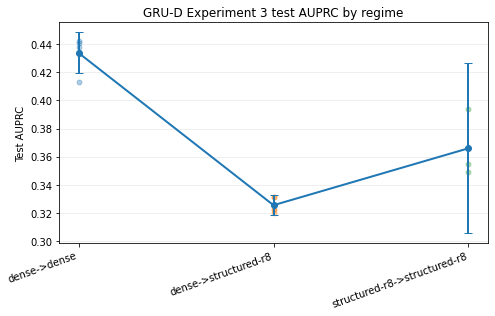

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_grud_test_auprc_by_regime_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI shown as zero-length.


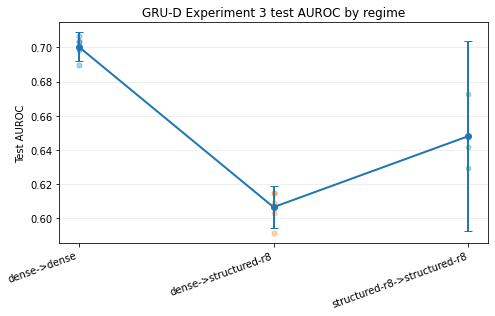

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_grud_test_auroc_by_regime_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI shown as zero-length.


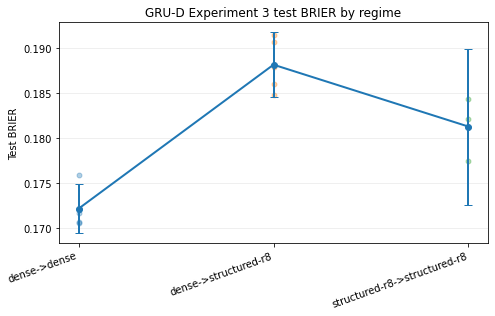

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_grud_test_brier_by_regime_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI shown as zero-length.


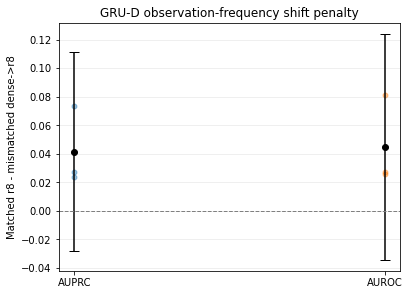

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_grud_shift_penalty_auprc_auroc_ci95.png
Error bars = 95% Student-t CI across model seeds.


In [9]:
def plot_test_performance_by_regime(metric):
    metric_col = "test_{}".format(metric)
    if len(exp3_grud_run_results) == 0 or metric_col not in exp3_grud_run_results.columns:
        print("Skipping {} plot: no GRU-D run results.".format(metric))
        return
    order = ["dense->dense", "dense->structured-r8", "structured-r8->structured-r8"]
    plot_rows = exp3_grud_run_results[exp3_grud_run_results["condition"].isin(order)].copy()
    if len(plot_rows) == 0:
        print("Skipping {} plot: no requested regimes.".format(metric))
        return
    summary = summarize_with_t_ci(plot_rows, ["condition"], metric_col)
    summary["order"] = summary["condition"].apply(lambda x: order.index(x) if x in order else 999)
    summary = summary.sort_values("order")
    x = np.arange(len(summary))
    yerr = summary["ci95"].fillna(0.0).values
    plt.figure(figsize=(7.0, 4.5))
    plt.errorbar(x, summary["mean"].values, yerr=yerr, marker="o", capsize=4, linewidth=2)
    for i, condition in enumerate(summary["condition"].tolist()):
        raw = plot_rows[plot_rows["condition"] == condition]
        plt.scatter(np.repeat(i, len(raw)), raw[metric_col].values, alpha=0.35, s=24)
    plt.xticks(x, summary["condition"].tolist(), rotation=20, ha="right")
    plt.ylabel("Test {}".format(metric.upper()))
    plt.title("GRU-D Experiment 3 test {} by regime".format(metric.upper()))
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    output_path = EXP3_GRUD_OUTPUT_DIR / "experiment3_grud_test_{}_by_regime_ci95.png".format(metric)
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)
    print("Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI shown as zero-length.")


def plot_shift_penalty():
    if len(exp3_grud_shift_summary) == 0:
        print("Skipping GRU-D shift penalty plot: no shift summary.")
        return
    sub = exp3_grud_shift_summary[exp3_grud_shift_summary["metric"].isin(["auprc", "auroc"])].copy()
    if len(sub) == 0:
        print("Skipping GRU-D shift penalty plot: no AUPRC/AUROC rows.")
        return
    order = ["auprc", "auroc"]
    sub["order"] = sub["metric"].apply(lambda x: order.index(x))
    sub = sub.sort_values("order")
    x = np.arange(len(sub))
    y = sub["mean_difference"].values
    lo = sub["student_t_ci95_low"].values
    hi = sub["student_t_ci95_high"].values
    yerr = np.vstack([y - lo, hi - y])
    yerr = np.nan_to_num(yerr, nan=0.0)
    plt.figure(figsize=(5.8, 4.2))
    plt.axhline(0, color="gray", linewidth=1, linestyle="--")
    plt.errorbar(x, y, yerr=yerr, fmt="o", capsize=5, color="black")
    for i, metric in enumerate(sub["metric"].tolist()):
        raw = exp3_grud_shift_contrasts[exp3_grud_shift_contrasts["metric"] == metric]
        plt.scatter(np.repeat(i, len(raw)), raw["difference"].values, alpha=0.45, s=24)
    plt.xticks(x, [m.upper() for m in sub["metric"].tolist()])
    plt.ylabel("Matched r8 - mismatched dense->r8")
    plt.title("GRU-D observation-frequency shift penalty")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    output_path = EXP3_GRUD_OUTPUT_DIR / "experiment3_grud_shift_penalty_auprc_auroc_ci95.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)
    print("Error bars = 95% Student-t CI across model seeds.")


plot_test_performance_by_regime("auprc")
plot_test_performance_by_regime("auroc")
plot_test_performance_by_regime("brier")
plot_shift_penalty()

## Optional LSTM Comparison

This section does not mix LSTM into the main GRU-D analysis. It only looks for already-saved LSTM Experiment 3 summaries and prints a compact comparison if they are available. Missing files are skipped without failing the notebook.

In [10]:
def load_lstm_shift_summary_if_available():
    candidate_paths = [
        EXP3_GRUD_OUTPUT_DIR / "experiment3_lstm_shift_summary.csv",
        EXP3_GRUD_OUTPUT_DIR / "experiment3_structured_shift_summary.csv",
        EXP3_GRUD_OUTPUT_DIR / "exp3_structured_shift_summary.csv",
    ]
    for candidate in candidate_paths:
        if candidate.exists():
            print("Using LSTM summary:", candidate)
            return pd.read_csv(candidate)
    if "exp3_structured_shift_summary" in globals():
        print("Using in-memory exp3_structured_shift_summary from this kernel.")
        return exp3_structured_shift_summary.copy()
    print("Skipping optional LSTM comparison: no saved LSTM Experiment 3 summary found.")
    return pd.DataFrame()


def extract_lstm_comparison_rows(lstm_summary):
    if lstm_summary is None or len(lstm_summary) == 0:
        return pd.DataFrame()
    df = lstm_summary.copy()
    if "metric" not in df.columns:
        return pd.DataFrame()
    if "r" in df.columns:
        df = df[df["r"].astype(str) == str(EXP3_GRUD_R)]
    if "contrast" in df.columns:
        df = df[df["contrast"].astype(str).str.contains("structured", case=False, na=False)]
    rows = []
    for metric in ["auprc", "auroc"]:
        sub = df[df["metric"].astype(str).str.lower().isin([metric, "test_{}".format(metric)])]
        if len(sub) == 0:
            continue
        row = sub.iloc[0]
        value_col = "mean_difference" if "mean_difference" in sub.columns else "mean"
        rows.append({
            "Model": "LSTM",
            "Metric": metric.upper(),
            "matched sparse - mismatched sparse": row.get(value_col, np.nan),
        })
    return pd.DataFrame(rows)


comparison_rows = []
lstm_rows = extract_lstm_comparison_rows(load_lstm_shift_summary_if_available())
if len(lstm_rows):
    comparison_rows.append(lstm_rows)
if len(exp3_grud_shift_summary):
    grud_rows = exp3_grud_shift_summary[exp3_grud_shift_summary["metric"].isin(["auprc", "auroc"])].copy()
    if len(grud_rows):
        comparison_rows.append(pd.DataFrame({
            "Model": "GRU-D",
            "Metric": grud_rows["metric"].str.upper(),
            "matched sparse - mismatched sparse": grud_rows["mean_difference"],
        }))

model_comparison_table = pd.concat(comparison_rows, ignore_index=True) if comparison_rows else pd.DataFrame()
show_table("Optional LSTM vs GRU-D shift comparison", model_comparison_table, max_rows=20)
print("Interpretation guardrail: this table is descriptive only; do not claim relative robustness without the actual intervals/results supporting it.")

Skipping optional LSTM comparison: no saved LSTM Experiment 3 summary found.

Optional LSTM vs GRU-D shift comparison


,Metric,Model,matched sparse - mismatched sparse
0,AUPRC,GRU-D,0.041469
1,AUROC,GRU-D,0.044880


Interpretation guardrail: this table is descriptive only; do not claim relative robustness without the actual intervals/results supporting it.


## Provenance Summary

- Logs/checkpoints are detected from GRU-D-only filenames: `k_grud*.csv`, never `k_lstm*.csv`.
- Dense logs are scanned in `results/fixed_horizon_icu_exit/12h/keras_logs`.
- Structured-r8 logs are scanned in `results/fixed_horizon_icu_exit/structured/12h/8h/keras_logs`.
- Best checkpoints are selected by maximum validation AUPRC in the validation CSV. The selected CSV epoch is zero-based; checkpoint filenames use `epoch = selected CSV epoch + 1`.
- Included train/test regimes are `dense -> dense`, `dense -> structured-r8`, and `structured-r8 -> structured-r8`.
- Normalizer selection is based on the training regime: dense training uses the dense training normalizer; structured-r8 training uses the structured-r8 training normalizer. The test regime never determines the normalizer.